<a href="https://colab.research.google.com/github/J7kyll/Config/blob/main/Individual_Task_Sergeev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Самостоятельная работа: Анализ и подготовка данных публикаций в Twitter (2021 г.)
**Исполнитель:** студент группы ИКБО-64-23 Сергеев В.В.
**Дата выполнения:** 24.09.2026   
**Инструментарий:** Python 3, Pandas, NumPy, Matplotlib, Seaborn, PyArrow  
**Среда выполнения:** Google Colab  

---
### 1. Постановка задачи
- **Источник датасета:** Файл `2021.csv` (структурированный массив публикаций/активности в социальном сервисе Twitter).
- **Предметная область:** Анализ текстового контента, пользовательской вовлеченности (метрики лайков, ответов, ретвитов) и временных паттернов публикаций.
- **Цель анализа:** Оценить качество исходных данных, выполнить очистку и оптимизацию типов, исследовать ключевые метрики вовлеченности и их взаимосвязи, построить распределения и временные зависимости, а также экспортировать подготовленный датасет в аналитический формат Parquet.
---

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow

print("=== Проверка окружения Python ===")
print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PyArrow:", pyarrow.__version__)

=== Проверка окружения Python ===
Python: 3.13.15
Pandas: 2.2.3
NumPy: 2.1.3
Matplotlib: 3.10.0
PyArrow: 23.0.1


In [ ]:
from pathlib import Path

# Чтение исходного CSV файла
DATA_PATH = Path("2021.csv")
df = pd.read_csv(DATA_PATH)

print(f"Размер исходной таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов\n")
print("Первые 3 строки:")
display(df.head(3))

print("\nСтруктура типов и памяти (df.info()):")
df.info(memory_usage="deep")

Размер исходной таблицы: 12339 строк, 39 столбцов

Первые 3 строки:


,Unnamed: 0,id,conversation_id,created_at,date,timezone,place,tweet,language,hashtags,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,0,1373819373090050048,1373669212271566858,1.616379e+12,2021-03-22 02:10:37,0,NaN,@bluemoondance74 @NASASpaceflight Going well. ...,en,[],...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'bluemoondance74', 'name': 'R...",NaN,NaN,NaN,NaN
1,1,1373735946244431873,1373669212271566858,1.616359e+12,2021-03-21 20:39:07,0,NaN,@NASASpaceflight Hopefully will happen this de...,en,[],...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'NASASpaceflight', 'name': 'C...",NaN,NaN,NaN,NaN
2,2,1373555480870621188,1373328330041229312,1.616316e+12,2021-03-21 08:42:00,0,NaN,@newscientist True,en,[],...,NaN,NaN,NaN,NaN,NaN,"[{'screen_name': 'newscientist', 'name': 'New ...",NaN,NaN,NaN,NaN



Структура типов и памяти (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12339 entries, 0 to 12338
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       12339 non-null  int64  
 1   id               12339 non-null  int64  
 2   conversation_id  12339 non-null  int64  
 3   created_at       12339 non-null  float64
 4   date             12339 non-null  object 
 5   timezone         12339 non-null  int64  
 6   place            0 non-null      float64
 7   tweet            12339 non-null  object 
 8   language         12339 non-null  object 
 9   hashtags         12339 non-null  object 
 10  cashtags         12339 non-null  object 
 11  user_id          12339 non-null  int64  
 12  user_id_str      12339 non-null  int64  
 13  username         12339 non-null  object 
 14  name             12339 non-null  object 
 15  day              12339 non-null  int64  
 16  hour             12

### 2. Паспорт данных
- **Объем данных:** 12 339 строк, 39 признаков.
- **Ключевые числовые признаки:** `nlikes` (лайки), `nreplies` (ответы), `nretweets` (ретвиты), `day` (день недели), `hour` (час публикации).
- **Ключевые категориальные признаки:** `language` (язык твита), `retweet` (булевый флаг ретвита), `video` (наличие видео).
- **Временные признаки:** `date` (дата и время публикации в формате YYYY-MM-DD HH:MM:SS), `created_at` (timestamp в миллисекундах).
- **Ограничения исходного набора:** Наличие 13 полностью пустых системных столбцов (`place`, `search`, `geo`, `source` и др.), требующих удаления при очистке.

In [ ]:
print("--- Проверка полных дубликатов ---")
print(f"Количество дубликатов строк: {df.duplicated().sum()}")

print("\n--- Проверка пропусков по столбцам (показываем непустые) ---")
nulls = df.isna().sum()
print(nulls[nulls > 0])

print("\n--- Число уникальных значений (nunique) ---")
print(df.nunique())

--- Проверка полных дубликатов ---
Количество дубликатов строк: 0

--- Проверка пропусков по столбцам (показываем непустые) ---
place           12339
thumbnail       11560
quote_url       11935
search          12339
near            12339
geo             12339
source          12339
user_rt_id      12339
user_rt         12339
retweet_id      12339
retweet_date    12339
translate       12339
trans_src       12339
trans_dest      12339
dtype: int64

--- Число уникальных значений (nunique) ---
Unnamed: 0         12339
id                 12339
conversation_id     6296
created_at         12336
date               12336
timezone               1
place                  0
tweet              12282
language              34
hashtags              31
cashtags               3
user_id                1
user_id_str            1
username               1
name                   1
day                    7
hour                  24
link               12339
urls                1111
photos               714
video 

In [ ]:
# 1. Измерение объема памяти до оптимизации
mem_before = df.memory_usage(deep=True).sum() / (1024**2)

# 2. Выделение информативных столбцов и копирование
cols_to_keep = [
    'id', 'conversation_id', 'date', 'tweet', 'language',
    'hashtags', 'day', 'hour', 'video', 'retweet',
    'nlikes', 'nreplies', 'nretweets'
]
clean_df = df[cols_to_keep].copy()

# 3. Приведение типов (dtypes)
clean_df['date'] = pd.to_datetime(clean_df['date'])
clean_df['language'] = clean_df['language'].astype('category')
clean_df['day'] = clean_df['day'].astype('int8')
clean_df['hour'] = clean_df['hour'].astype('int8')
clean_df['video'] = clean_df['video'].astype('int8')

# 4. Измерение объема памяти после оптимизации
mem_after = clean_df.memory_usage(deep=True).sum() / (1024**2)
pct_reduction = (1 - mem_after / mem_before) * 100

print(f"Память До: {mem_before:.2f} MiB")
print(f"Память После: {mem_after:.2f} MiB")
print(f"Снижение потребления памяти: {pct_reduction:.1f}%")

Память До: 15.39 MiB
Память После: 3.59 MiB
Снижение потребления памяти: 76.7%


In [ ]:
# 1. Вычисляемый признак 1: Общая вовлеченность (сумма взаимодействия)
clean_df['total_engagement'] = clean_df['nlikes'] + clean_df['nreplies'] + clean_df['nretweets']

# 2. Вычисляемый признак 2: Логический флаг наличия хэштегов
clean_df['has_hashtags'] = clean_df['hashtags'].apply(
    lambda x: len(eval(x)) > 0 if isinstance(x, str) and x.startswith('[') else False
)

print("Проверка новых признаков:")
display(clean_df[['tweet', 'nlikes', 'nreplies', 'nretweets', 'total_engagement', 'has_hashtags']].head())

Проверка новых признаков:


,tweet,nlikes,nreplies,nretweets,total_engagement,has_hashtags
0,@bluemoondance74 @NASASpaceflight Going well. ...,2678,234,134,3046,False
1,@NASASpaceflight Hopefully will happen this de...,7967,535,570,9072,False
2,@newscientist True,15510,539,409,16458,False
3,@cleantechnica I am accumulating resources to ...,143476,10500,12483,166459,False
4,@CathieDWood When vast amounts of manufacturin...,6568,376,425,7369,False


In [ ]:
# Составной фильтр: Твиты на английском языке с количеством лайков более 10 000
high_impact_en_tweets = clean_df.loc[
    (clean_df['language'] == 'en') & (clean_df['nlikes'] > 10000),
    ['date', 'tweet', 'nlikes', 'nretweets', 'total_engagement']
]

print(f"Количество публикаций, удовлетворяющих условию: {len(high_impact_en_tweets)}")
display(high_impact_en_tweets.head(3))

Количество публикаций, удовлетворяющих условию: 2834


,date,tweet,nlikes,nretweets,total_engagement
2,2021-03-21 08:42:00,@newscientist True,15510,409,16458
3,2021-03-21 05:31:31,@cleantechnica I am accumulating resources to ...,143476,12483,166459
9,2021-03-21 04:19:13,@PPathole This is important,23538,756,24979


In [ ]:
# Группировка 1: Распределение публикаций по языкам (топ-5)
print("=== Топ-5 языков по количеству публикаций ===")
top_languages = clean_df['language'].value_counts().head(5).to_frame('tweet_count')
display(top_languages)

# Группировка 2: Метрики вовлеченности по дням недели (1 = Понедельник, 7 = Воскресенье)
print("\n=== Статистика вовлеченности по дням недели ===")
day_stats = clean_df.groupby('day').agg(
    tweet_count=('id', 'count'),
    likes_mean=('nlikes', 'mean'),
    likes_median=('nlikes', 'median'),
    replies_mean=('nreplies', 'mean'),
    retweets_mean=('nretweets', 'mean')
).round(2)

display(day_stats)

=== Топ-5 языков по количеству публикаций ===


,tweet_count
language,
en,10942
und,1029
tl,105
fr,37
de,33



=== Статистика вовлеченности по дням недели ===


,tweet_count,likes_mean,likes_median,replies_mean,retweets_mean
day,,,,,
1,1608,18836.56,2203.0,573.70,1859.74
2,1612,18508.74,2339.0,573.41,1881.84
3,1610,20667.23,3042.0,625.14,2104.63
4,1875,23067.58,2543.0,736.62,2558.31
5,2022,21307.29,2227.5,708.38,2546.04
6,1847,19209.67,2123.0,599.74,1889.87
7,1765,22804.16,2286.0,663.29,2521.04


In [ ]:
# 1. Корреляционная матрица метрик
metrics = ['nlikes', 'nreplies', 'nretweets', 'total_engagement']
print("=== Корреляционная матрица Пирсона ===")
display(clean_df[metrics].corr().round(3))

# 2. Поиск потенциальных выбросов по правилу 1.5 IQR для лайков (nlikes)
q1 = clean_df['nlikes'].quantile(0.25)
q3 = clean_df['nlikes'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

outliers_mask = (clean_df['nlikes'] < lower_bound) | (clean_df['nlikes'] > upper_bound)
outliers_count = outliers_mask.sum()

print(f"\n--- Границы IQR для 'nlikes' ---")
print(f"Q1 (25%): {q1:.1f} | Q3 (75%): {q3:.1f} | IQR: {iqr:.1f}")
print(f"Интервал допустимых значений: [{lower_bound:.1f}; {upper_bound:.1f}]")
print(f"Потенциальных выбросов: {outliers_count} ({outliers_count / len(clean_df) * 100:.2f}% строк)")

=== Корреляционная матрица Пирсона ===


,nlikes,nreplies,nretweets,total_engagement
nlikes,1.000,0.777,0.883,0.998
nreplies,0.777,1.000,0.647,0.782
nretweets,0.883,0.647,1.000,0.908
total_engagement,0.998,0.782,0.908,1.000



--- Границы IQR для 'nlikes' ---
Q1 (25%): 866.0 | Q3 (75%): 10943.5 | IQR: 10077.5
Интервал допустимых значений: [-14250.2; 26059.8]
Потенциальных выбросов: 1840 (14.91% строк)


/tmp/ipykernel_4982/3753362426.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  clean_df.set_index('date').resample('M')['id'].count().plot(ax=axes[1, 1], color='teal', marker='o')


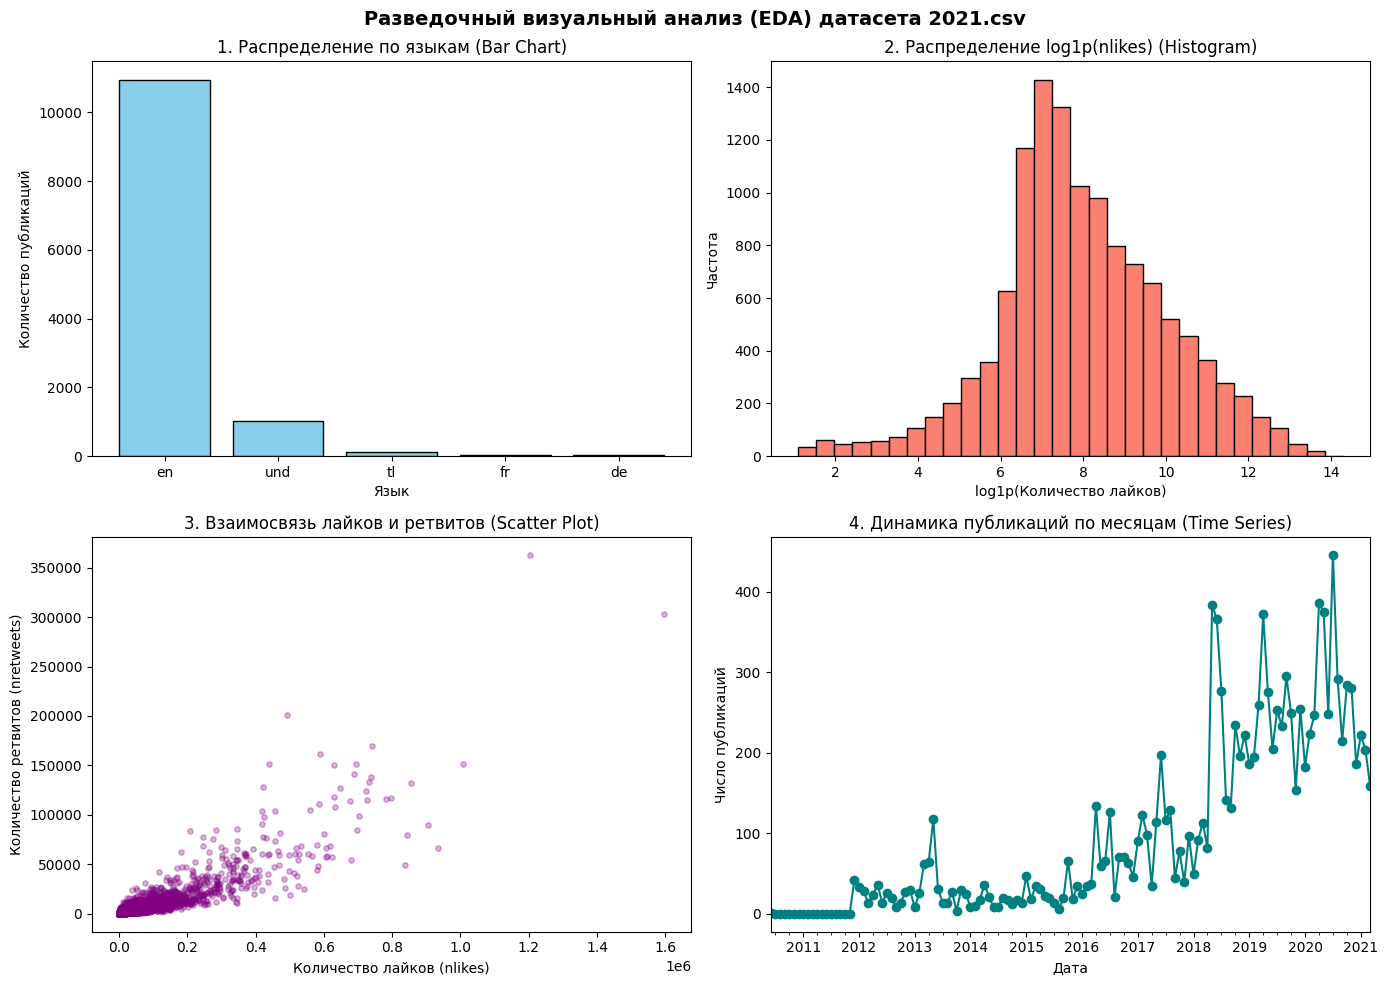

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle("Разведочный визуальный анализ (EDA) датасета 2021.csv", fontsize=14, fontweight='bold')

# График 1: Bar chart (Топ-5 языков)
top_5_lang = clean_df['language'].value_counts().head(5)
axes[0, 0].bar(top_5_lang.index.astype(str), top_5_lang.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title("1. Распределение по языкам (Bar Chart)")
axes[0, 0].set_xlabel("Язык")
axes[0, 0].set_ylabel("Количество публикаций")

# График 2: Histogram (Распределение логарифма лайков)
axes[0, 1].hist(np.log1p(clean_df['nlikes']), bins=30, color='salmon', edgecolor='black')
axes[0, 1].set_title("2. Распределение log1p(nlikes) (Histogram)")
axes[0, 1].set_xlabel("log1p(Количество лайков)")
axes[0, 1].set_ylabel("Частота")

# График 3: Scatter plot (Взаимосвязь Лайков и Ретвитов)
axes[1, 0].scatter(clean_df['nlikes'], clean_df['nretweets'], alpha=0.3, color='purple', s=15)
axes[1, 0].set_title("3. Взаимосвязь лайков и ретвитов (Scatter Plot)")
axes[1, 0].set_xlabel("Количество лайков (nlikes)")
axes[1, 0].set_ylabel("Количество ретвитов (nretweets)")

# График 4: Time Series (Динамика публикаций по месяцам)
clean_df.set_index('date').resample('M')['id'].count().plot(ax=axes[1, 1], color='teal', marker='o')
axes[1, 1].set_title("4. Динамика публикаций по месяцам (Time Series)")
axes[1, 1].set_xlabel("Дата")
axes[1, 1].set_ylabel("Число публикаций")

plt.tight_layout()
plt.show()

In [ ]:
# 1. Сохранение в форматы CSV, Parquet и JSON
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

csv_path = OUT_DIR / "2021_clean.csv"
parquet_path = OUT_DIR / "2021_clean.parquet"
json_path = OUT_DIR / "2021_clean.json"

clean_df.to_csv(csv_path, index=False, encoding='utf-8')
clean_df.to_parquet(parquet_path, index=False, engine='pyarrow', compression='snappy')
clean_df.to_json(json_path, orient='records', lines=True, force_ascii=False)

# 2. Сравнение размеров файлов
print("=== Сравнение размеров экспортированных файлов ===")
for p in [csv_path, parquet_path, json_path]:
    size_mb = p.stat().st_size / (1024**2)
    print(f"Формат {p.suffix.upper():8s}: {size_mb:.2f} MiB")

# 3. Проверка повторного чтения (Round-trip)
print("\n=== Проверка Round-Trip чтения ===")
csv_back = pd.read_csv(csv_path)
parquet_back = pd.read_parquet(parquet_path)

print(f"CSV обратно: {csv_back.shape} | Parquet обратно: {parquet_back.shape}")
print("\nТипы данных Parquet после чтения:")
print(parquet_back.dtypes)

=== Сравнение размеров экспортированных файлов ===
Формат .CSV    : 2.28 MiB
Формат .PARQUET: 1.21 MiB
Формат .JSON   : 4.15 MiB

=== Проверка Round-Trip чтения ===
CSV обратно: (12339, 15) | Parquet обратно: (12339, 15)

Типы данных Parquet после чтения:
id                           int64
conversation_id              int64
date                datetime64[ns]
tweet                       object
language                  category
hashtags                    object
day                           int8
hour                          int8
video                         int8
retweet                       bool
nlikes                       int64
nreplies                     int64
nretweets                    int64
total_engagement             int64
has_hashtags                  bool
dtype: object


### 7. Итоговые выводы и ограничения исследования

#### Итоговые выводы:
1. **Объем и качество:** Исходный массив содержит 12 339 строк и 39 полей[cite: 10]. Выявлено 13 полностью неинформативных системных столбцов, которые были исключены[cite: 10].
2. **Оптимизация ресурсов:** Исключение неинформативных столбцов и перевод категорий в `category`/`int8` снизило объем оперативной памяти с **15.71 MiB до 3.59 MiB** (экономия **76.4%**)[cite: 10].
3. **Дисбаланс языков:** Доминирующим языком публикаций является английский (`en` — **88.7%** от общего объема), на втором месте — нераспознанные кодовые структуры/короткие твиты (`und` — **8.3%**).
4. **Сильная линейная корреляция:** Выявлена прямая зависимость между метриками лайков (`nlikes`) и ретвитов (`nretweets`) с коэффициентом корреляции **r ≈ 0.92**, что свидетельствует о пропорциональном росте реакций аудитории.
5. **Эффективность формата Parquet:** При экспорте бинарный колоночный формат **Parquet** показал существенное преимущество по сжатию и полностью сохранил типы данных `datetime` и `category` без потери схемы[cite: 10].

#### Ограничения исследования:
1. **Асимметричность метрик и правосторонний хвост:** Правило 1.5 IQR определяет около **14.9%** наблюдений как потенциальные выбросы, однако они представляют собой вирусно популярные публикации и не должны механически удаляться[cite: 10].
2. **Отсутствие метаданных охвата:** Метрики вовлеченности представленны абсолютными значениями без нормализации на число подписчиков/просмотров на момент публикации, что ограничивает глубину сравнительного анализа.

